In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from pyprojroot import here
%run ../Scripts/utils.py

In [2]:
data_path = here("Data/FPL_data_tidy.parquet")
data = pd.read_parquet(data_path)

In [3]:
data.head()

,name,position,team,xp,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,gw,season_id,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts,modified
0,Alex Scott,MID,Bournemouth,1.6,0,0,11,0,12.8,77,6,1,0,3.6,22.8,2024-08-17T14:00:00Z,62,16,0,0,0,0,1,0,4339,1,1,0.0,2,0,0,0,50,False,0,1,2024-25,0.01,0.01,0.0,1.02,1.0,False
1,Carlos Miguel dos Santos Pereira,GK,Nott'm Forest,2.2,0,0,0,0,0.0,427,6,0,0,0.0,0.0,2024-08-17T14:00:00Z,0,3,0,0,0,0,1,0,33324,1,1,0.0,0,0,0,0,45,True,0,1,2024-25,0.00,0.00,0.0,0.00,0.0,False
2,Tomiyasu Takehiro,DEF,Arsenal,0.0,0,0,0,0,0.0,22,2,0,0,0.0,0.0,2024-08-17T14:00:00Z,0,20,0,0,0,0,1,0,8462,0,2,0.0,0,0,0,0,50,True,0,1,2024-25,0.00,0.00,0.0,0.00,0.0,False
3,Malcolm Ebiowei,MID,Crystal Palace,0.0,0,0,0,0,0.0,197,8,0,0,0.0,0.0,2024-08-18T13:00:00Z,0,4,0,0,0,0,1,0,716,1,2,0.0,0,0,0,0,45,False,0,1,2024-25,0.00,0.00,0.0,0.00,0.0,False
4,Ben Brereton Díaz,MID,Southampton,1.0,0,0,-2,0,14.0,584,5,1,0,3.3,2.6,2024-08-17T14:00:00Z,70,15,0,0,0,0,1,0,66244,0,1,16.0,1,0,0,0,55,False,1,1,2024-25,0.02,0.32,0.3,0.25,1.0,False


In [4]:
data.shape

(45788, 43)

In [5]:
features_now = [
    "position", "team", "was_home", "opponent_team", "value",
    "season_id", "selected", "transfers_balance",
    "transfers_in", "transfers_out", "xp"
]
cols_to_lag = [
    "total_points", "minutes", "goals_scored", "assists", "bonus", "bps",
    "clean_sheets", "creativity", "goals_conceded", "ict_index",
    "influence", "own_goals", "penalties_missed", "penalties_saved",
    "red_cards", "saves", "threat", "yellow_cards", "starts",
    "expected_assists", "expected_goal_involvements", "expected_goals",
    "expected_goals_conceded", "team_h_score", "team_a_score"
]

cols_id = [
    "name", "element", "fixture", "kickoff_time",
    "round", "gw", "modified"
]
len(features_now+cols_id+cols_to_lag)

43

In [6]:
def ema(df:pd.DataFrame,
        cols_to_lag:list[str] | None,
        window_size:int=4)->tuple[pd.DataFrame, list[str]]:

    if cols_to_lag is None:
        return df.copy(), []

    df = sort_data(df).copy()

    ema_frame = df.groupby(["name", "season_id"])[cols_to_lag].transform(lambda x: x.ewm(span=window_size, adjust=False).mean().shift(1))

    new_cols = [f"{c}_ema_{window_size}" for c in cols_to_lag]
    df[new_cols] = ema_frame.fillna(0)
    return df, new_cols


In [7]:
def lagged_features(df:pd.DataFrame,
                    cols_to_lag:list[str] | None,
                    lag_size:int=1)->tuple[pd.DataFrame, list[str]]:
    if cols_to_lag is None:
        return df.copy(), []

    df = sort_data(df).copy()
    lagged_frame = df.groupby(["name", "season_id"])[cols_to_lag].transform(lambda x: x.shift(lag_size))
    new_cols = [f"{c}_lagged_{lag_size}" for c in cols_to_lag]
    df[new_cols] = lagged_frame.fillna(0)

    return df, new_cols

In [8]:
data, ema_cols = ema(df=data,
                        cols_to_lag=cols_to_lag,
                        window_size=4)
data, lagged_cols = lagged_features(df=data,
                        cols_to_lag=cols_to_lag)


In [9]:
data.shape

(45788, 93)

In [10]:
data_lagged = data.drop(columns=[c for c in cols_to_lag if c != "total_points"])

In [11]:
data_lagged["points_momentum"] = data_lagged.total_points_lagged_1 - data_lagged.total_points_ema_4

In [12]:
data_lagged.shape, data_lagged.drop(columns=lagged_cols+ema_cols).shape, data.shape

((45788, 70), (45788, 20), (45788, 93))

In [13]:
corr_lagged_features = data_lagged.select_dtypes(np.number).corr()["total_points"].nlargest(10).index

corr_features = data.select_dtypes(np.number).corr()["total_points"].nlargest(10).index


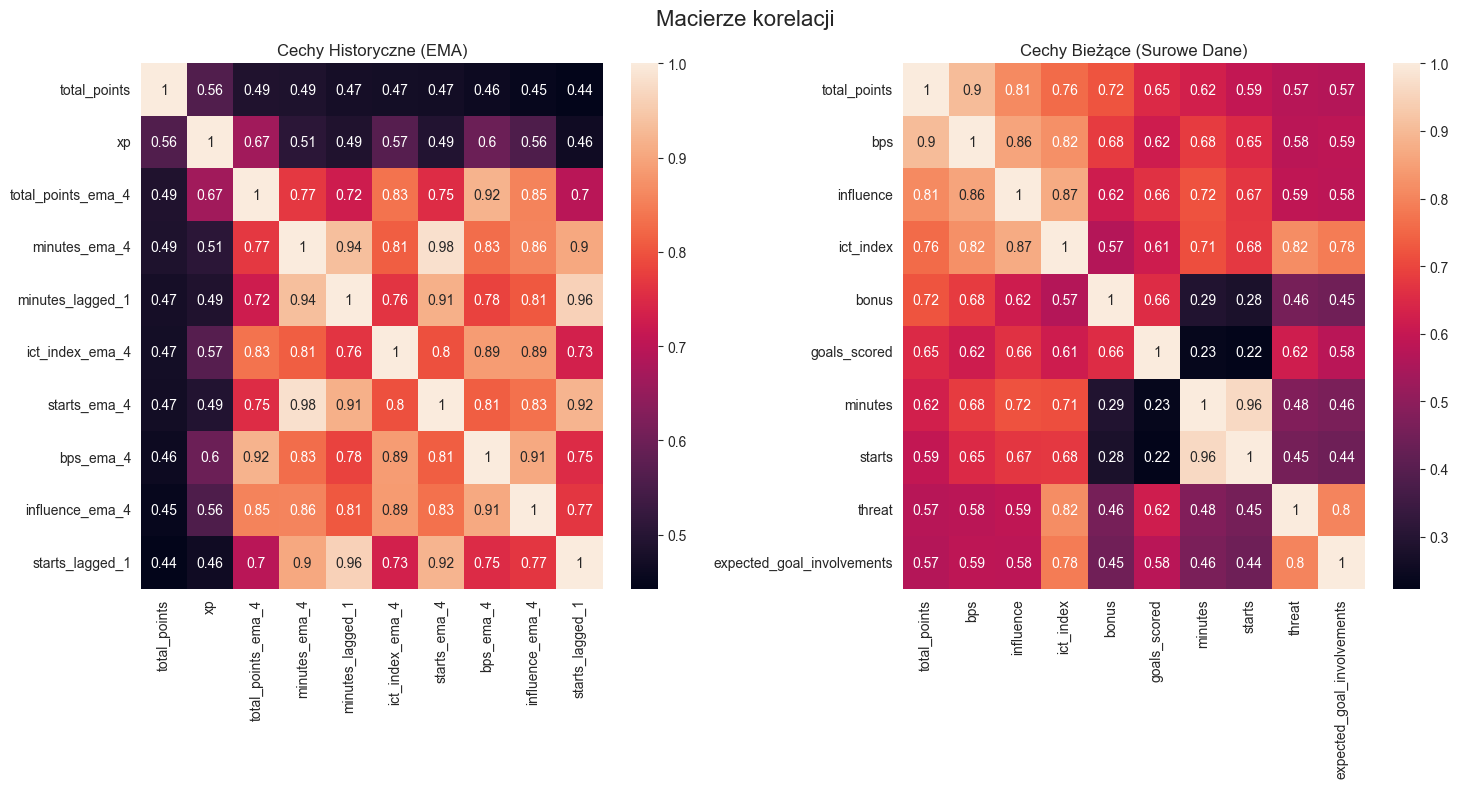

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,8))

sns.heatmap(data_lagged[corr_lagged_features].corr(), annot=True, ax=ax[0])
sns.heatmap(data[corr_features].corr(), annot=True, ax=ax[1])

fig.suptitle("Macierze korelacji", fontsize=16)

ax[0].set_title("Cechy Historyczne (EMA)")
ax[1].set_title("Cechy Bieżące (Surowe Dane)")

plt.tight_layout()

In [15]:
data_lagged.shape

(45788, 70)

In [16]:
c = data_lagged.select_dtypes(np.number).corr().abs()
s = c.unstack().drop_duplicates()
high_corr_pairs = s[(s > 0.9) & (s < 1)]
to_drop = set([p[1] for p in high_corr_pairs.index if p[1] != 'total_points'])
data_lagged = data_lagged.drop(columns=to_drop)


data_lagged.shape

(45788, 60)

In [17]:
data_lagged.head()

,name,position,team,xp,element,fixture,kickoff_time,opponent_team,selected,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,gw,season_id,modified,total_points_ema_4,minutes_ema_4,goals_scored_ema_4,assists_ema_4,bonus_ema_4,clean_sheets_ema_4,creativity_ema_4,goals_conceded_ema_4,ict_index_ema_4,own_goals_ema_4,penalties_missed_ema_4,penalties_saved_ema_4,red_cards_ema_4,saves_ema_4,threat_ema_4,yellow_cards_ema_4,expected_assists_ema_4,expected_goal_involvements_ema_4,expected_goals_conceded_ema_4,team_h_score_ema_4,team_a_score_ema_4,total_points_lagged_1,goals_scored_lagged_1,assists_lagged_1,bonus_lagged_1,clean_sheets_lagged_1,creativity_lagged_1,goals_conceded_lagged_1,ict_index_lagged_1,influence_lagged_1,own_goals_lagged_1,penalties_missed_lagged_1,penalties_saved_lagged_1,red_cards_lagged_1,threat_lagged_1,yellow_cards_lagged_1,expected_assists_lagged_1,expected_goal_involvements_lagged_1,expected_goals_conceded_lagged_1,team_h_score_lagged_1,team_a_score_lagged_1,points_momentum
0,Alex Scott,MID,Bournemouth,1.6,77,6,2024-08-17T14:00:00Z,16,4339,2,0,0,0,50,False,1,2024-25,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Carlos Miguel dos Santos Pereira,GK,Nott'm Forest,2.2,427,6,2024-08-17T14:00:00Z,3,33324,0,0,0,0,45,True,1,2024-25,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Tomiyasu Takehiro,DEF,Arsenal,0.0,22,2,2024-08-17T14:00:00Z,20,8462,0,0,0,0,50,True,1,2024-25,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Malcolm Ebiowei,MID,Crystal Palace,0.0,197,8,2024-08-18T13:00:00Z,4,716,0,0,0,0,45,False,1,2024-25,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Ben Brereton Díaz,MID,Southampton,1.0,584,5,2024-08-17T14:00:00Z,15,66244,1,0,0,0,55,False,1,2024-25,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
filename = "../Data/FPL_data.parquet"
data.to_parquet(filename,
                engine='pyarrow',
                index=False)